# XGBOOST

In [35]:
#path config set
import sys
from pathlib import Path

project_root = Path.cwd().parent
for folder in ["functions", "other"]:
    p = str(project_root / folder)
    if p not in sys.path:
        sys.path.append(p)

In [36]:
# import potrebnych kniznic a konfiguracia notebooku
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

    #import importlib
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

import shap

from cred import DATA_PATH_CRED
from functions_xgboost import make_features, rolling_forecast_xgboost, trace_path_for_observation, extract_tree_structure, hyperparameters_tuning
from functions_general import forecast_plot

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

plt.rcParams.update({
    "figure.figsize": (13, 4),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})


print("Importy uspesne.")


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Importy uspesne.


In [45]:
# konfiguracia a stiahnutie dat
main_dir = Path(DATA_PATH_CRED)
data_mod = "data_mod.csv"
pp_orig = "data.xlsx"
DATA_PATH_DATA_MOD  = main_dir / data_mod
DATA_PATH_DATA = main_dir / pp_orig
SHEET_NAME_PP = "pp"
SHEET_NAME_EXOG = "exog"
TEST_SIZE = 24
RANDOM_STATE = 24
TARGET_VAR = "pp_sa_ca_jd"

df_raw = pd.read_csv(DATA_PATH_DATA_MOD)
df_raw["datum"] = pd.to_datetime(df_raw["datum"])
df_raw = df_raw.set_index("datum").sort_index()
df_raw = df_raw.asfreq("MS")
df = df_raw.copy()

df_pp = pd.read_excel(DATA_PATH_DATA,SHEET_NAME_PP)
df_pp = df_pp.set_index("datum").sort_index()
df_pp = df_pp.asfreq("MS")


In [46]:
#definovanie features, train/test vzorka
exog_cols = df.drop(columns=[TARGET_VAR,"pp_non_sa","pp_sa_orig","cpi_non_sa", "oil_europe_usd"])
features = make_features(
    data=df,
    target=TARGET_VAR,
    exog_cols=exog_cols,
    target_lags=(1, 2, 3, 6, 12),
    exog_lags=(1,)
)

X = features.drop(columns = [TARGET_VAR, "pp_sa_ca_jd_lag1"])
y = features[TARGET_VAR]

X_train, X_test = X.iloc[:-TEST_SIZE], X.iloc[-TEST_SIZE:]
y_train, y_test = y.iloc[:-TEST_SIZE], y.iloc[-TEST_SIZE:]

print(f"Trenovacia mnozina: {y_train.index.min().date()} az {y_train.index.max().date()} ({len(y_train)} obs.)")
print(f"Testovacia mnozina: {y_test.index.min().date()} az {y_test.index.max().date()} ({len(y_test)} obs.)")


Trenovacia mnozina: 2001-02-01 az 2023-12-01 (275 obs.)
Testovacia mnozina: 2024-01-01 az 2025-12-01 (24 obs.)


In [47]:
grid_search, best_params = hyperparameters_tuning(X_train, y_train)

Fitting 5 folds for each of 60 candidates, totalling 300 fits
Najlepsie parametre z Random Search: {'subsample': 0.6, 'reg_lambda': 1, 'reg_alpha': 0.01, 'n_estimators': 200, 'min_child_weight': 1, 'max_depth': 4, 'learning_rate': 0.005, 'gamma': 1, 'colsample_bytree': 0.7}
Fitting 5 folds for each of 81 candidates, totalling 405 fits
Finalne parametre po Grid Search: {'colsample_bytree': 0.7, 'gamma': 0, 'learning_rate': 0.0025, 'max_depth': 5, 'min_child_weight': 1, 'n_estimators': 300, 'reg_alpha': 0.01, 'reg_lambda': 1, 'subsample': 0.6}


In [48]:
init_train_size = len(y) - TEST_SIZE
xgb_res = rolling_forecast_xgboost(
    X=X,
    y_diff= y,
    level_series=df_pp[TARGET_VAR],
    initial_train_size=init_train_size,
    xgb_params=best_params
)

RMSE (diferencia):      2.4930
RMSE (level, onestep):  2.4930
WMAPE (level):          1.92%
ME (level):             -0.4718
Refity:                 24 / 24


In [14]:
results_xgboost = xgb_res["results"]
results_xgboost.to_parquet("data/xgb_res")
diagnostics = xgb_res["diagnostics"]
fi = diagnostics['feature_importance']
hp = diagnostics['hyperparams']
refit_diag = xgb_res["refit_diagnostics"]
summary_xgb = xgb_res["summary"]
summary_xgb = pd.DataFrame([summary_xgb])
summary_xgb.to_parquet("data/xgb_sum")

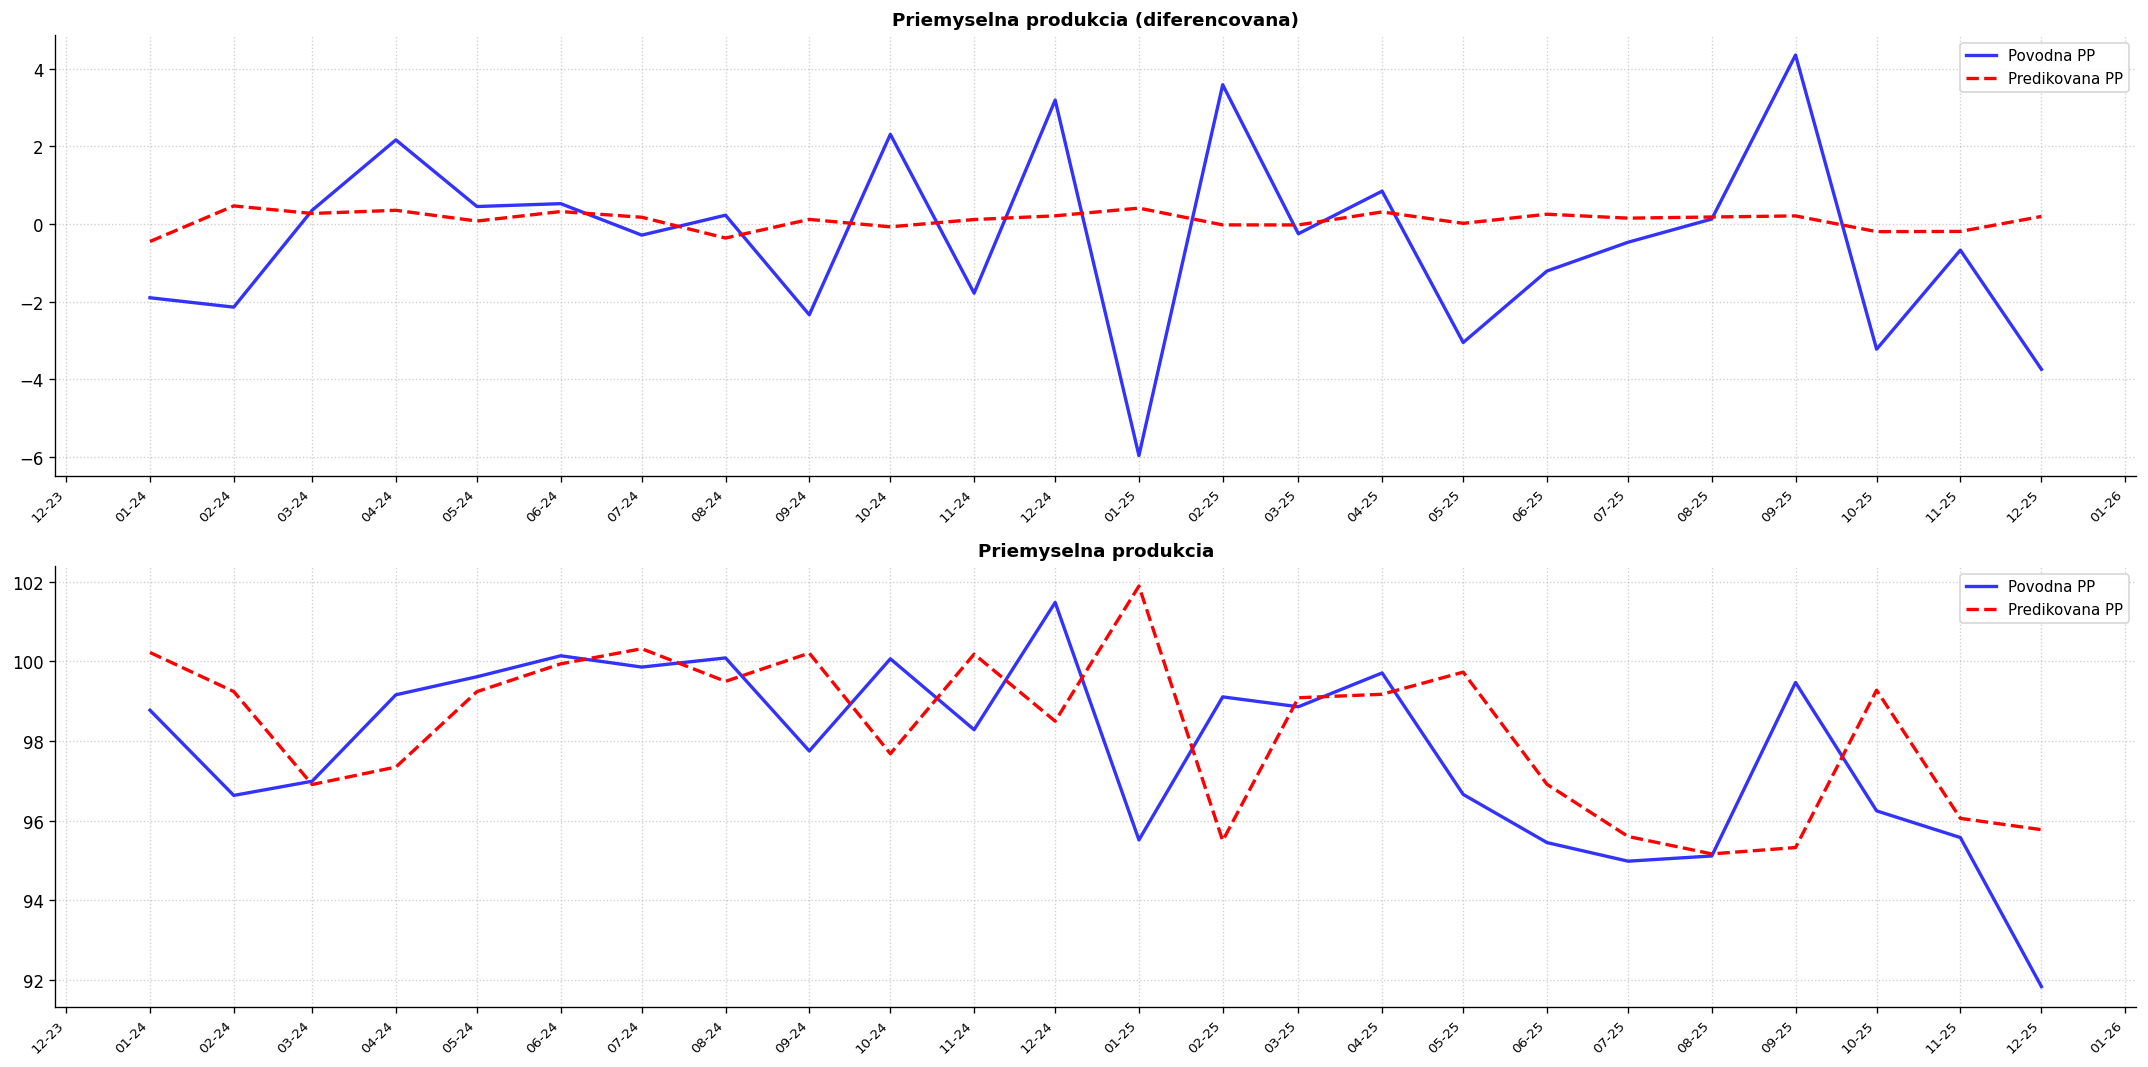

In [15]:
Y_axis = [results_xgboost["actual_diff"], results_xgboost["predicted_diff"], results_xgboost["actual_level"], results_xgboost["predicted_level"]]
X_axis = [results_xgboost.index] * len(Y_axis)
labels = ["Povodna PP", "Predikovana PP"] * len(Y_axis)
titles = ["Priemyselna produkcia (diferencovana)", "Priemyselna produkcia"]
colors = ["#0000FF", "#FF0000"] * len(Y_axis)
linestyles = ["-","--"] * len(Y_axis)
linewidths = [] * len(Y_axis)
alphas = [0.8,1] * len(Y_axis)
fig_size = [18,9]
num_rows = 2
num_cols = 1

_ = forecast_plot(X_axis,Y_axis,titles, labels, colors, linestyles, linewidths, alphas,fig_size, num_rows, num_cols)

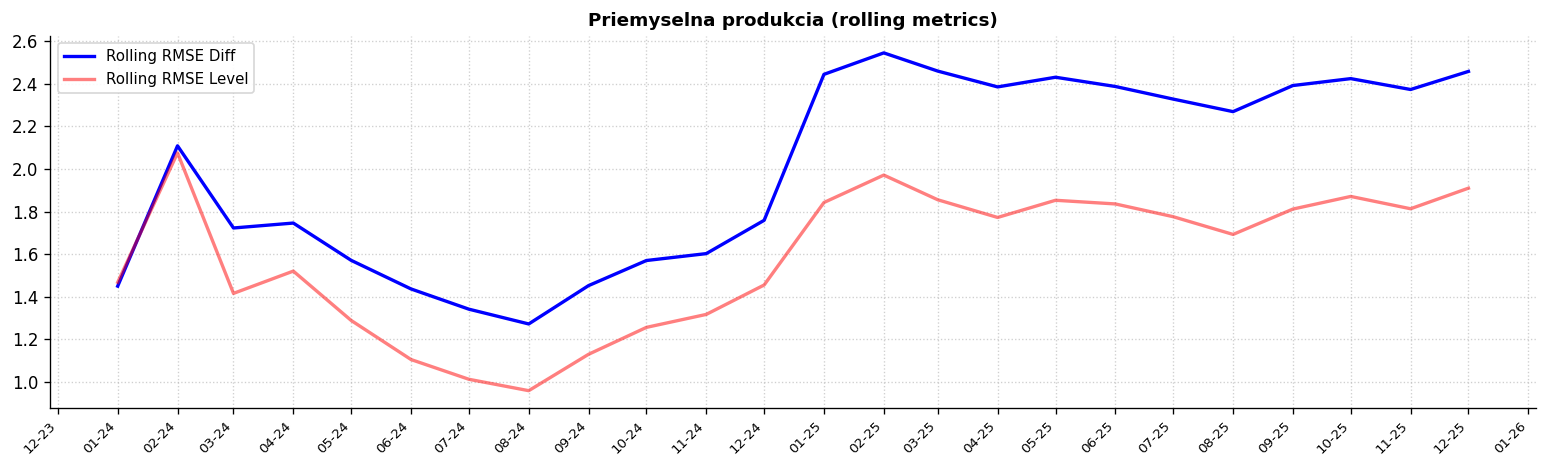

In [16]:
Y_axis = [results_xgboost["rolling_rmse_level"], results_xgboost["rolling_mape_level"]]
X_axis = [results_xgboost.index] * len(Y_axis)
labels = ["Rolling RMSE Diff", "Rolling RMSE Level", "Rolling MAPE Level"] * len(Y_axis)
titles = ["Priemyselna produkcia (rolling metrics)"]
colors = ["#0000FF", "#FF0000", "#008000"] * len(Y_axis)
linestyles = ["-"] * len(Y_axis)
linewidths = [] * len(Y_axis)
alphas = [1, 0.5, 1] * len(Y_axis)
fig_size = [13,4]
num_rows = 1
num_cols = 1
curves_per_plot = 3

_ = forecast_plot(X_axis,Y_axis,titles, labels, colors, linestyles, linewidths, alphas,fig_size, num_rows, num_cols, curves_per_plot)

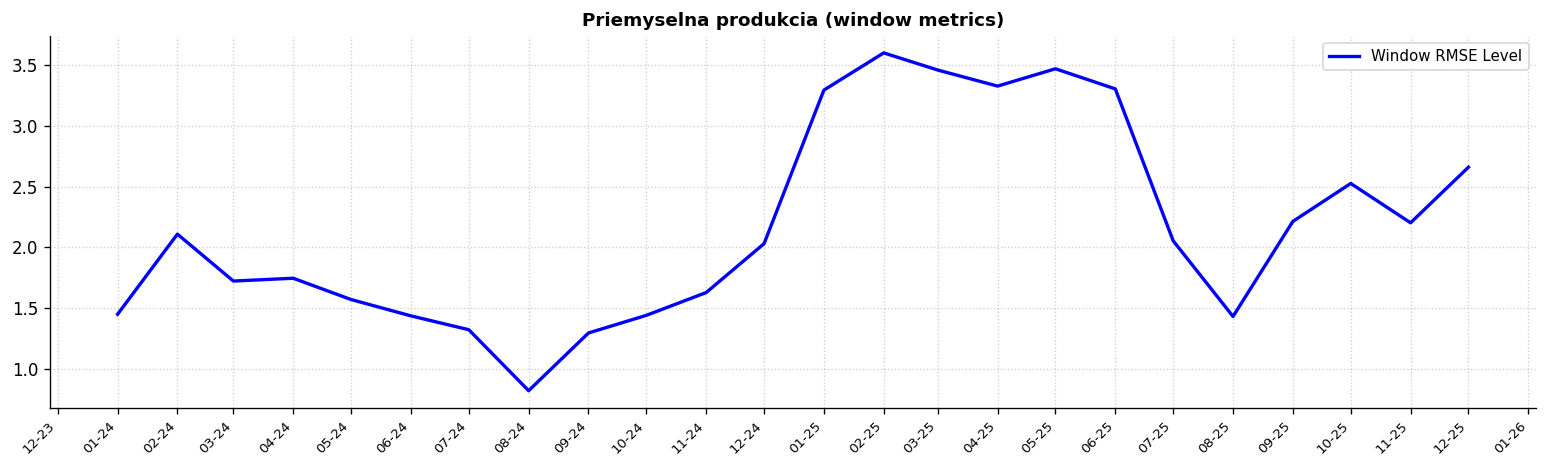

In [17]:
Y_axis = [results_xgboost["window6_rmse_level"]] #results_xgboost["window6_mape_level"], results_xgboost["window6_me_level"]
X_axis = [results_xgboost.index] * len(Y_axis)
labels = ["Window RMSE Level"] * len(Y_axis) #, "Window MAPE Level", "Window ME Level"
titles = ["Priemyselna produkcia (window metrics)"]
colors = ["#0000FF"] * len(Y_axis) #, "#FF0000", "#008000"
linestyles = ["-"] * len(Y_axis)
linewidths = [] * len(Y_axis)
alphas = [1] * len(Y_axis)
fig_size = [13,4]
num_rows = 1
num_cols = 1
curves_per_plot = 3

_ = forecast_plot(X_axis,Y_axis,titles, labels, colors, linestyles, linewidths, alphas,fig_size, num_rows, num_cols, curves_per_plot)

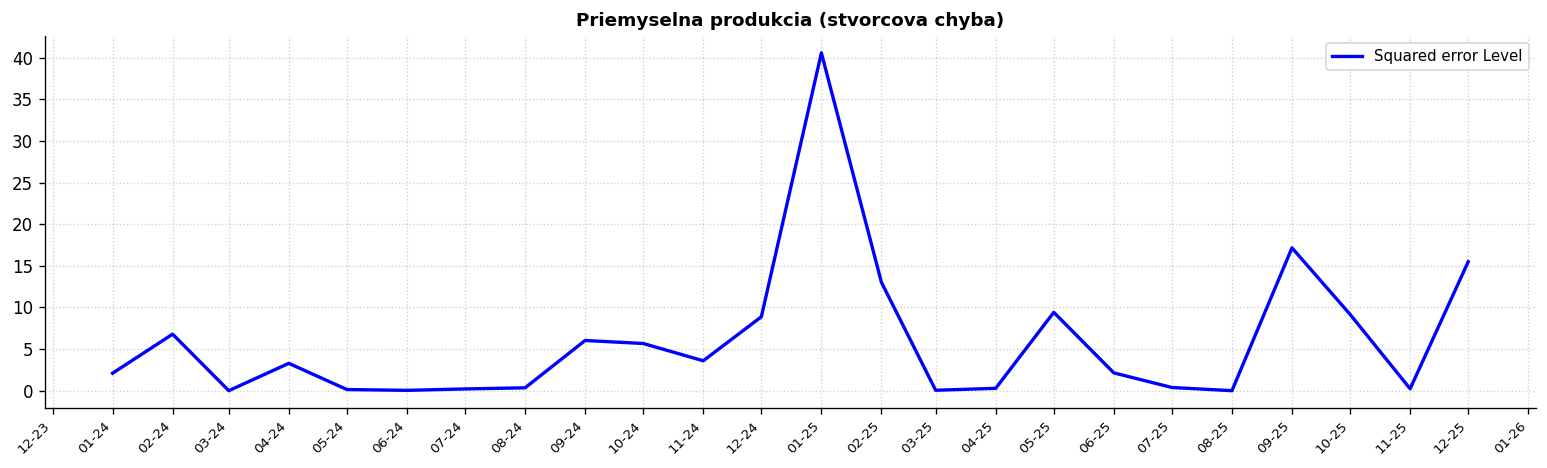

In [18]:
Y_axis = [results_xgboost["sq_error_level"]]
X_axis = [results_xgboost.index] * len(Y_axis)
labels = ["Squared error Level"] * len(Y_axis)
titles = ["Priemyselna produkcia (stvorcova chyba)"]
colors = ["#0000FF"] * len(Y_axis)
linestyles = ["-"] * len(Y_axis)
linewidths = [] * len(Y_axis)
alphas = [1] * len(Y_axis)
fig_size = [13,4]
num_rows = 1
num_cols = 1
curves_per_plot = 3

_ = forecast_plot(X_axis,Y_axis,titles, labels, colors, linestyles, linewidths, alphas,fig_size, num_rows, num_cols, curves_per_plot)

In [19]:
print(xgb_res.keys())

dict_keys(['results', 'models_by_step', 'refit_diagnostics', 'step_diagnostics', 'misaligned_dates', 'summary', 'diagnostics'])


In [20]:
#shap
models_by_step = xgb_res["models_by_step"]
last_date = max(models_by_step.keys())
xgb_model = models_by_step[last_date]

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)
shap_summary = pd.DataFrame(shap_values, columns = X_test.columns, index = X_test.index)
mean_abs_shap = np.abs(shap_summary).mean().sort_values(ascending=False)
mean_abs_shap

expected_industry_production_lag1     0.095359
vklady_nefinancne_podniky_lag1        0.035636
pp_sa_ca_jd_lag6                      0.033644
industry_confidence_sa_lag1           0.030416
trzby_priemysel_sa_lag1               0.025684
infl_cpi_lag1                         0.019105
economic_sentiment_lag1               0.017725
ipcv_priemysel_lag1                   0.016700
oil_price_eur_lag1                    0.016674
cdd_lag1                              0.014323
current_total_demand_sa_lag1          0.014052
expected_employment_lag1              0.012689
oil_europe_eur_lag1                   0.012435
index_lag1                            0.010644
pp_sa_ca_jd_lag2                      0.009817
pp_sa_ca_jd_lag12                     0.009240
kurz_usd_eur_lag1                     0.008330
expected_product_prices_lag1          0.006265
uvery_celkom_lag1                     0.005877
pp_sa_ca_jd_lag3                      0.005621
cpi_sa_lag1                           0.005420
hdd_lag1     

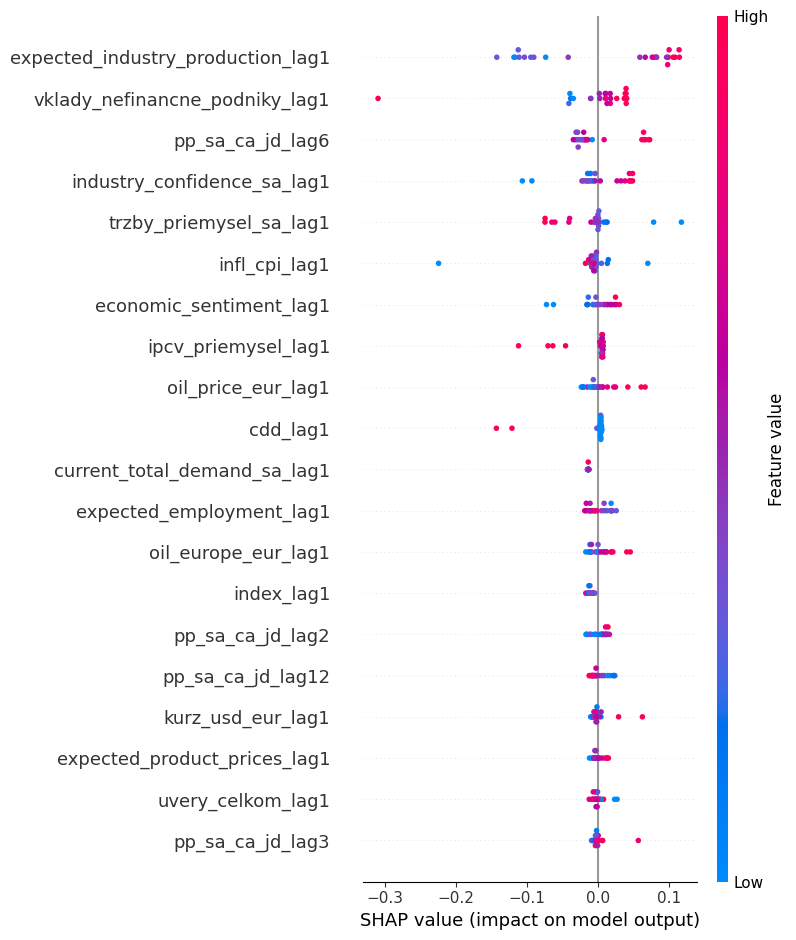

In [21]:
#graf ku shapu
shap.summary_plot(shap_values, X_test)

In [22]:
shap_rows = []

for forecast_date, xgb_model in models_by_step.items():

    X_one = X_test.loc[[forecast_date]].copy()

    explainer = shap.TreeExplainer(xgb_model)
    shap_one = explainer(X_one)

    for feature, value, contribution in zip(X_one.columns, X_one.iloc[0].values, shap_one.values[0]):
        shap_rows.append(
            {
                "forecast_date": forecast_date,
                "feature": feature,
                "feature_value": value,
                "shap_value": contribution,
                "abs_shap_value": abs(contribution),
            }
        )

shap_long = pd.DataFrame(shap_rows)
shap_long


,forecast_date,feature,feature_value,shap_value,abs_shap_value
0,2024-01-01,pp_sa_ca_jd_lag2,-2.366972,-0.008936,0.008936
1,2024-01-01,pp_sa_ca_jd_lag3,2.416140,0.053328,0.053328
2,2024-01-01,pp_sa_ca_jd_lag6,-5.675175,-0.031538,0.031538
3,2024-01-01,pp_sa_ca_jd_lag12,8.032883,-0.008293,0.008293
4,2024-01-01,index_lag1,286.000000,-0.001775,0.001775
...,...,...,...,...,...
811,2025-12-01,oil_europe_eur_lag1,-0.304100,-0.000801,0.000801
812,2025-12-01,crisis_dummy_lag1,0.000000,0.000000,0.000000
813,2025-12-01,month,12.000000,0.003577,0.003577
814,2025-12-01,quarter,4.000000,0.000000,0.000000


In [23]:
shap_global = (
    shap_long
    .groupby("feature", as_index= False)
    .agg(
        mean_abs_shap = ("abs_shap_value", "mean"),
        mean_shap = ("shap_value", "mean"),
        median_abs_shap=("abs_shap_value", "median"),
    )
    .sort_values("mean_abs_shap", ascending=False)
)

print(shap_global.head(15).to_string(index=False))

                          feature  mean_abs_shap  mean_shap  median_abs_shap
expected_industry_production_lag1       0.098349   0.011450         0.102082
   vklady_nefinancne_podniky_lag1       0.052743  -0.010457         0.039751
                 pp_sa_ca_jd_lag6       0.037495  -0.000479         0.029584
          trzby_priemysel_sa_lag1       0.037192   0.007200         0.007710
      industry_confidence_sa_lag1       0.035865   0.000986         0.027560
                         cdd_lag1       0.022667  -0.015553         0.004034
          economic_sentiment_lag1       0.021212   0.000379         0.013687
               oil_price_eur_lag1       0.016440   0.001871         0.010058
              oil_europe_eur_lag1       0.016218   0.000110         0.013327
                    infl_cpi_lag1       0.013864  -0.004935         0.007841
     current_total_demand_sa_lag1       0.013681  -0.013681         0.013880
                kurz_usd_eur_lag1       0.012962  -0.001016         0.008341

In [24]:
trees_df = extract_tree_structure(xgb_model)

In [25]:
# iba listove uzly (vahy) jedneho konkretneho stromu
tree_0_leaves = trees_df[(trees_df["Tree"] == 0) & (trees_df["Feature"] == "Leaf")]
print(tree_0_leaves[["Tree", "Node", "Gain", "Cover"]])

    Tree  Node      Gain  Cover
1      0     1 -0.028935    1.0
3      0     3  0.021433    2.0
7      0     7 -0.016472    3.0
8      0     8 -0.002848   21.0
9      0     9  0.000105   90.0
10     0    10  0.003687   48.0


In [26]:
#najcastejsie pouzivane premenne na delenie
split_counts = (
    trees_df[trees_df["Feature"] != "Leaf"]
    .groupby("Feature")
    .size()
    .sort_values(ascending=False)
)
print(split_counts)

Feature
pp_sa_ca_jd_lag2                      189
expected_industry_production_lag1     103
export_celkovy_sa_lag1                 84
vklady_nefinancne_podniky_lag1         83
oil_price_eur_lag1                     80
pp_sa_ca_jd_lag3                       75
trzby_priemysel_sa_lag1                74
infl_cpi_lag1                          67
pp_sa_ca_jd_lag6                       64
oil_europe_eur_lag1                    62
current_total_demand_sa_lag1           60
industry_confidence_sa_lag1            56
pp_sa_ca_jd_lag12                      51
cpi_sa_lag1                            37
economic_sentiment_lag1                32
ipcv_priemysel_lag1                    29
kurz_usd_eur_lag1                      28
index_lag1                             27
sadzba_3m_euribor_lag1                 27
hdd_lag1                               26
uvery_celkom_lag1                      22
cdd_lag1                               21
expected_employment_lag1               21
sh_prices_non_sa_lag1     

In [27]:
#priemerny Gain pri deleni podla premennej
avg_gain_by_feature = (
    trees_df[trees_df["Feature"] != "Leaf"]
    .groupby("Feature")["Gain"]
    .mean()
    .sort_values(ascending=False)
)
print(avg_gain_by_feature)

Feature
oil_europe_eur_lag1                   172.478426
current_total_demand_sa_lag1          172.394713
oil_price_eur_lag1                    171.881835
export_celkovy_sa_lag1                146.151155
foreign_demand_sa_lag1                118.851405
expected_industry_production_lag1     113.052769
industry_confidence_sa_lag1           112.607095
trzby_priemysel_sa_lag1               105.271987
vklady_nefinancne_podniky_lag1          95.27302
economic_sentiment_lag1                87.052999
cdd_lag1                               86.989261
infl_cpi_lag1                          86.159393
pp_sa_ca_jd_lag2                       81.530965
finished_goods_inventories_sa_lag1     73.972426
kurz_usd_eur_lag1                      67.400761
cpi_sa_lag1                            62.309895
month                                  61.239251
pp_sa_ca_jd_lag6                       61.140461
ipcv_priemysel_lag1                    60.199671
hdd_lag1                               57.869292
sadzba_3m_eu

In [28]:
#kompletna struktura jedneho konkretneho stromu
last_tree = trees_df.iloc[-1, 0]
tree_last_full = trace_path_for_observation(trees_df, tree_index=last_tree)
print(tree_last_full)

      Node                       Feature      Split    Yes     No       Gain  \
3009     0           oil_europe_eur_lag1 -13.923057  199-1  199-2  207.74417   
3010     1                          Leaf       <NA>   <NA>   <NA>  -0.025087   
3011     2  current_total_demand_sa_lag1      -51.0  199-3  199-4  162.88562   
3012     3                          Leaf       <NA>   <NA>   <NA>   0.018803   
3013     4                      cdd_lag1      46.37  199-5  199-6   71.72575   
3014     5              pp_sa_ca_jd_lag2   7.969917  199-7  199-8   53.15821   
3015     6                          Leaf       <NA>   <NA>   <NA>  -0.014662   
3016     7                          Leaf       <NA>   <NA>   <NA>   0.000558   
3017     8                          Leaf       <NA>   <NA>   <NA>  -0.010053   

      Cover  
3009  190.0  
3010    1.0  
3011  189.0  
3012    2.0  
3013  187.0  
3014  186.0  
3015    1.0  
3016  184.0  
3017    2.0  


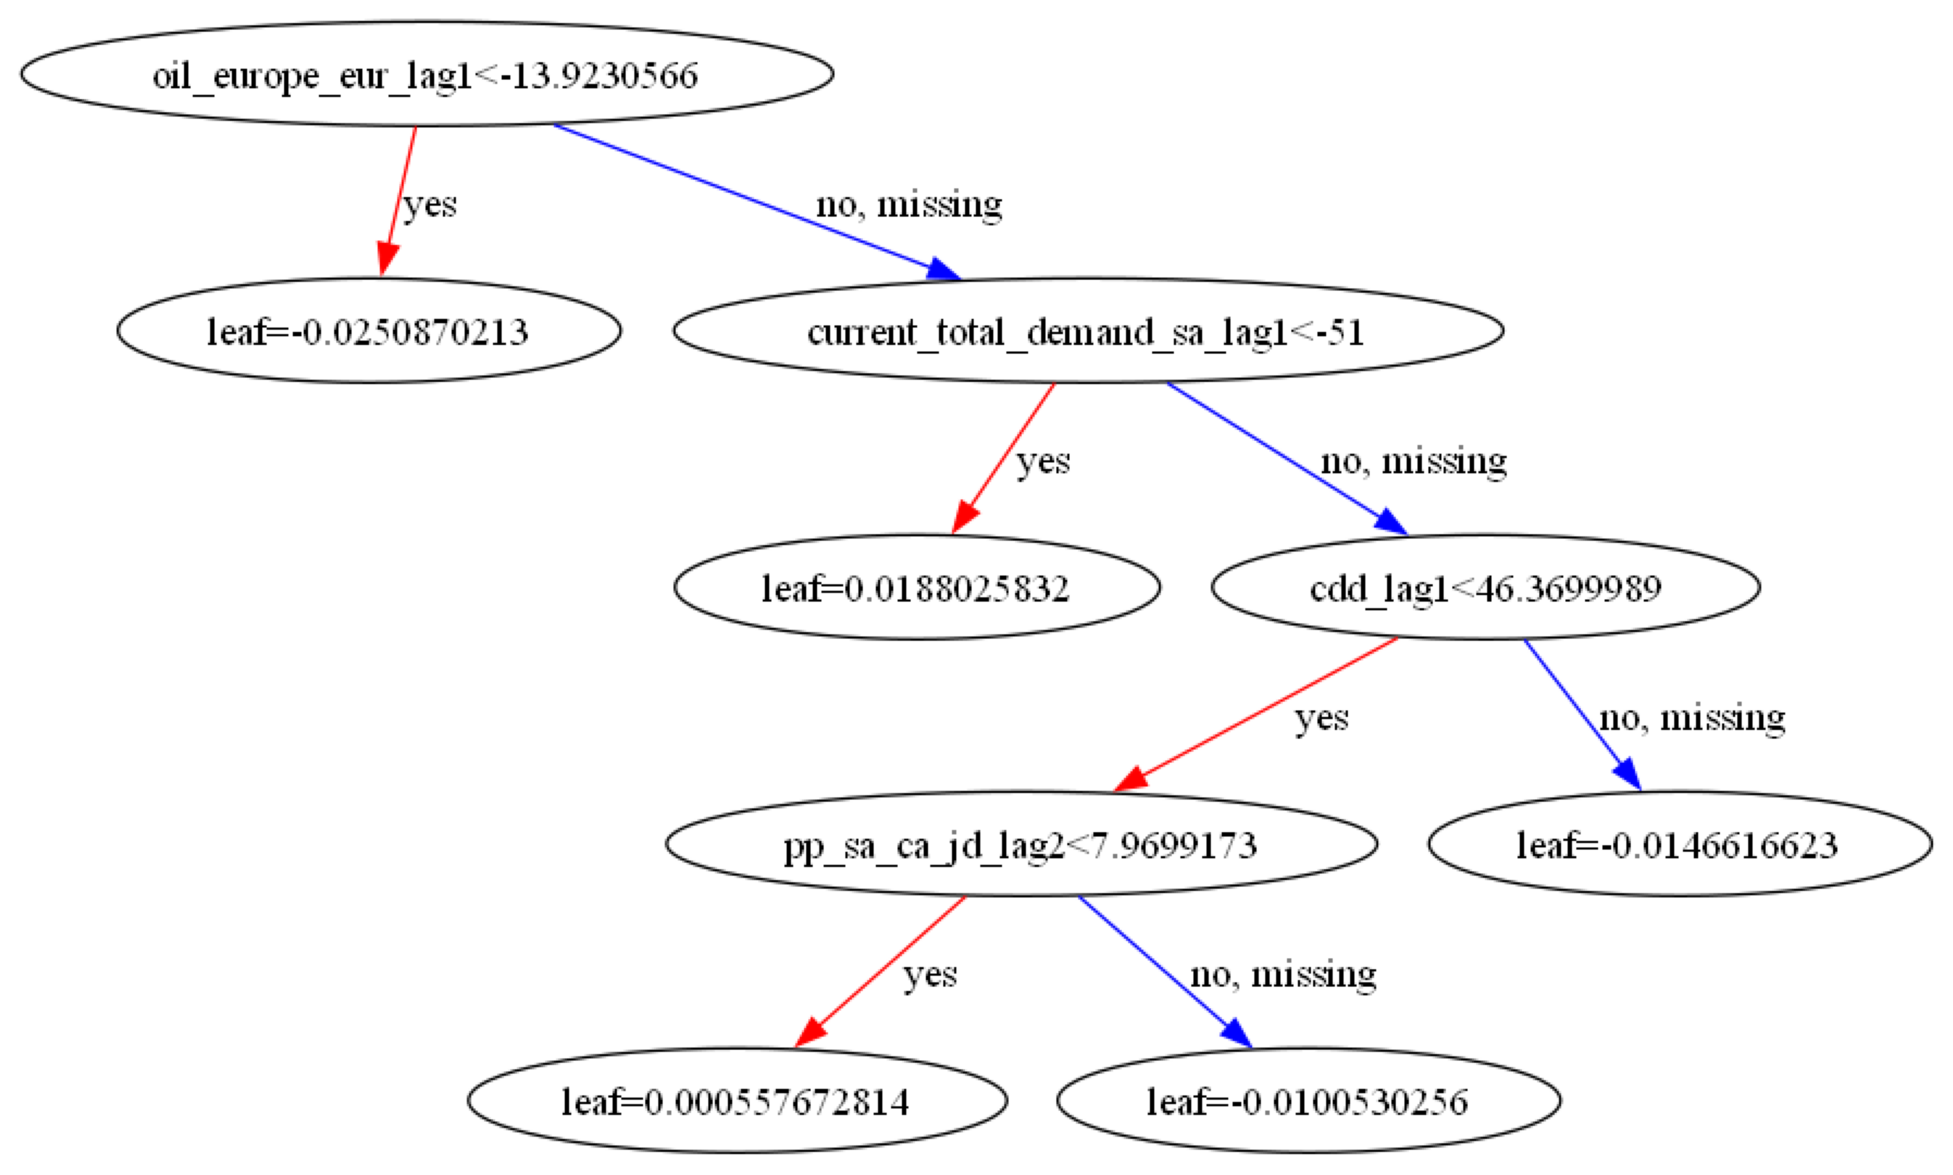

In [29]:
#graficke zobrazenie stromu
from xgboost import plot_tree
import matplotlib.pyplot as plt

plot_tree(xgb_model, num_trees=last_tree)
fig = plt.gcf()
fig.set_size_inches(30, 15)

In [30]:
#Pocet listov a vnutornych uzlov pre kazdy strom
tree_summary = trees_df.groupby("Tree").agg(
    n_nodes=("Node", "count"),
    n_leaves=("Feature", lambda x: (x == "Leaf").sum()),
).reset_index()

# pre binarny strom: n_splits = n_leaves - 1
tree_summary["n_splits"] = tree_summary["n_leaves"] - 1

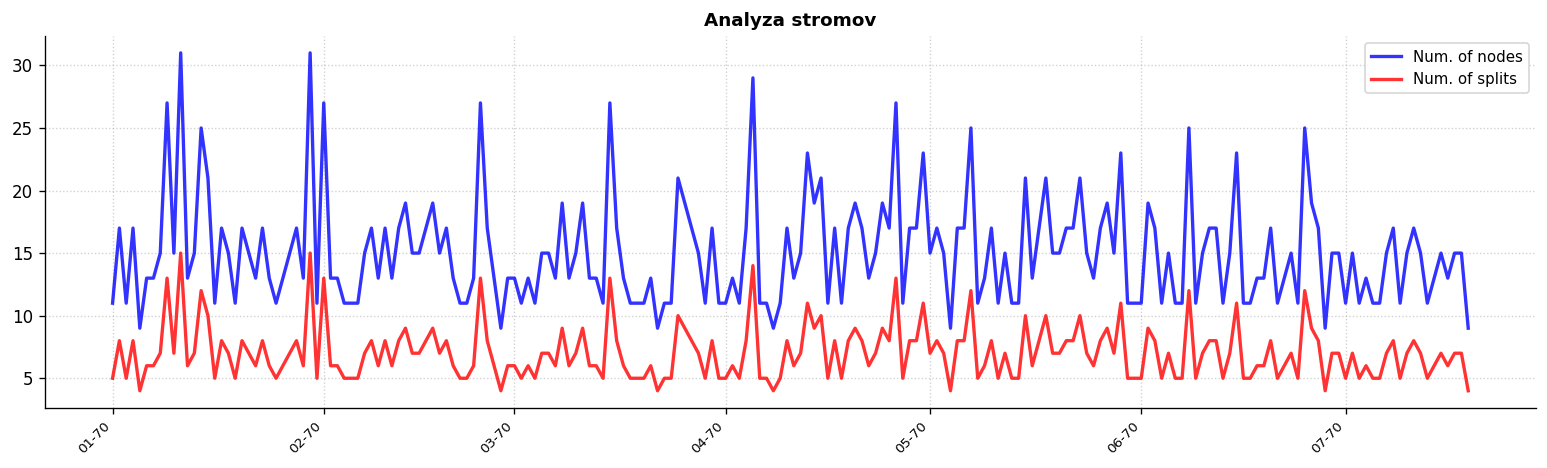

In [ ]:
Y_axis = [tree_summary["n_nodes"],tree_summary["n_splits"]]
X_axis = [tree_summary["Tree"]] * len(Y_axis)
labels = ["Num. of nodes", "Num. of splits"] * len(Y_axis)
titles = ["Analyza stromov"]
colors = ["#0000FF", "#FF0000"] * len(Y_axis)
linestyles = ["-"] * len(Y_axis)
linewidths = [] * len(Y_axis)
alphas = [0.8] * len(Y_axis)
fig_size = [13,4]
num_rows = 1
num_cols = 1
curves_per_plot = 3

_ = forecast_plot(X_axis,Y_axis,titles, labels, colors, linestyles, linewidths, alphas,fig_size, num_rows, num_cols, curves_per_plot) #UPRAVIT OS X

In [32]:
#Zakladna statistika - kolko stromov ma 0, 1, 2+ deleni
split_distribution = tree_summary["n_splits"].value_counts().sort_index()
print("Rozdelenie poctu deleni naprieč stromami:")
print(split_distribution)

n_trivial = (tree_summary["n_splits"] == 0).sum()
n_single_split = (tree_summary["n_splits"] > 1).sum()
n_multi_split = (tree_summary["n_splits"] > 10).sum()

print(f"\nStromy bez delenia (len 1 list):       {n_trivial}")
print(f"Stromy s viac ako 1 delenim (3+ listy):    {n_single_split}")
print(f"Stromy s viac ako 10 delenim (21+ listy): {n_multi_split}")


Rozdelenie poctu deleni naprieč stromami:
n_splits
4      7
5     51
6     35
7     36
8     38
9     11
10     6
11     4
12     4
13     5
14     1
15     2
Name: count, dtype: int64[pyarrow]

Stromy bez delenia (len 1 list):       0
Stromy s viac ako 1 delenim (3+ listy):    200
Stromy s viac ako 10 delenim (21+ listy): 16


In [33]:
#ktore konkretne stromy maju viac ako 1 delenie
trees_with_multi_splits = tree_summary[tree_summary["n_splits"] > 1].sort_values(
    "n_splits", ascending=False
)
print("\nStromy s viac ako 1 delenim (zoradene podla poctu deleni):")
print(trees_with_multi_splits)


Stromy s viac ako 1 delenim (zoradene podla poctu deleni):
     Tree  n_nodes  n_leaves  n_splits
10     10       31        16        15
29     29       31        16        15
94     94       29        15        14
8       8       27        14        13
31     31       27        14        13
..    ...      ...       ...       ...
80     80        9         5         4
97     97        9         5         4
123   123        9         5         4
178   178        9         5         4
199   199        9         5         4

[200 rows x 4 columns]


In [34]:
# Priemerny pocet deleni cez cely ansambel - rychly diagnosticky ukazovatel
avg_splits = tree_summary["n_splits"].mean()
pct_trivial = (n_trivial / len(tree_summary)) * 100
print(f"\nPriemerny pocet deleni na strom: {avg_splits:.2f}")
print(f"Podiel trivialnych (nerozdelenych) stromov: {pct_trivial:.1f}%")


Priemerny pocet deleni na strom: 7.04
Podiel trivialnych (nerozdelenych) stromov: 0.0%
